In [ ]:
import pandas as _hex_pandas
import datetime as _hex_datetime
import json as _hex_json

In [ ]:
hex_scheduled = _hex_json.loads("false")

In [ ]:
hex_user_email = _hex_json.loads("\"example-user@example.com\"")

In [ ]:
hex_user_attributes = _hex_json.loads("{}")

In [ ]:
hex_run_context = _hex_json.loads("\"logic\"")

In [ ]:
hex_timezone = _hex_json.loads("\"UTC\"")

In [ ]:
hex_project_id = _hex_json.loads("\"01a0d056-ecd4-771c-af6c-6206757143f8\"")

In [ ]:
hex_project_name = _hex_json.loads("\"healthcare\"")

In [ ]:
hex_status = _hex_json.loads("\"\"")

In [ ]:
hex_categories = _hex_json.loads("[]")

In [ ]:
hex_color_palette = _hex_json.loads("[\"#4C78A8\",\"#F58518\",\"#E45756\",\"#72B7B2\",\"#54A24B\",\"#EECA3B\",\"#B279A2\",\"#FF9DA6\",\"#9D755D\",\"#BAB0AC\"]")

In [ ]:
# import jinja2
# raw_query = """
#     -- Create a clean, standardized view/table directly from the uploaded CSV file
#     CREATE OR REPLACE TABLE clean_healthcare_dataset AS
#     WITH deduplicated AS (
#         SELECT DISTINCT
#             patientid,
#             -- Handle missing age by imputing median/average age
#             COALESCE(age, AVG(age) OVER()) AS cleaned_age,
#             
#             -- Standardize gender values and handle missing entries
#             COALESCE(NULLIF(TRIM(gender), ''), 'Unknown') AS cleaned_gender,
#             
#             -- Standardize text fields
#             COALESCE(NULLIF(TRIM(diagnosis), ''), 'Unspecified') AS cleaned_diagnosis,
#             COALESCE(NULLIF(TRIM(treatmenttype), ''), 'Unspecified') AS cleaned_treatmenttype,
#             
#             -- Parse admission_date string to DATE format
#             TRY_CAST(admission_date AS DATE) AS cleaned_admission_date
#         FROM 'synthetic_healthcare_dataset.csv'
#     )
#     SELECT 
#         patientid,
#         ROUND(cleaned_age, 0) AS age,
#         CASE 
#             WHEN cleaned_age < 18 THEN 'Pediatric (<18)'
#             WHEN cleaned_age BETWEEN 18 AND 35 THEN 'Young Adult (18-35)'
#             WHEN cleaned_age BETWEEN 36 AND 60 THEN 'Adult (36-60)'
#             ELSE 'Senior (61+)'
#         END AS age_group,
#         cleaned_gender AS gender,
#         cleaned_diagnosis AS diagnosis,
#         cleaned_treatmenttype AS treatmenttype,
#         cleaned_admission_date AS admission_date,
#         EXTRACT(YEAR FROM cleaned_admission_date) AS admission_year
#     FROM deduplicated
#     WHERE cleaned_admission_date IS NOT NULL;
# """
# sql_query = jinja2.Template(raw_query).render(vars())

In [ ]:
import pandas as pd

# Load original dataset
df = pd.read_csv("synthetic_healthcare_dataset.csv")

# Deduplicate rows
df_clean = df.drop_duplicates()

# Impute missing age with the average
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].mean()).round(0)

# Fill missing string values
df_clean['gender'] = df_clean['gender'].fillna('Unknown').str.strip().replace('', 'Unknown')
df_clean['diagnosis'] = df_clean['diagnosis'].fillna('Unspecified').str.strip().replace('', 'Unspecified')
df_clean['treatmenttype'] = df_clean['treatmenttype'].fillna('Unspecified').str.strip().replace('', 'Unspecified')

# Parse dates & drop records with missing dates
df_clean['admission_date'] = pd.to_datetime(df_clean['admission_date'], errors='coerce')
df_clean = df_clean.dropna(subset=['admission_date'])

# Create age groups and extraction fields
def assign_age_group(age):
    if age < 18:
        return 'Pediatric (<18)'
    elif age <= 35:
        return 'Young Adult (18-35)'
    elif age <= 60:
        return 'Adult (36-60)'
    else:
        return 'Senior (61+)'

df_clean['age_group'] = df_clean['age'].apply(assign_age_group)
df_clean['admission_year'] = df_clean['admission_date'].dt.year
df_clean['admission_date'] = df_clean['admission_date'].dt.strftime('%Y-%m-%d')

# Save to CSV
df_clean.to_csv("clean_healthcare_dataset.csv", index=False)
print("Successfully generated clean_healthcare_dataset.csv!")

Successfully generated clean_healthcare_dataset.csv!


#### Q1: Clinical Operations Lead

**What are the top 5 most frequent diagnoses, and what is the average patient age for each?**



In [ ]:
# import jinja2
# raw_query = """
#     SELECT 
#         diagnosis,
#         COUNT(patientid) AS total_cases,
#         ROUND(AVG(age), 1) AS avg_patient_age,
#         MIN(age) AS min_age,
#         MAX(age) AS max_age
#     FROM clean_healthcare_dataset
#     WHERE diagnosis != 'Unspecified'
#     GROUP BY diagnosis
#     ORDER BY total_cases DESC
#     LIMIT 5;
# """
# sql_query = jinja2.Template(raw_query).render(vars())

#### Q2: Executive Leadership & Strategy

**How has patient admission volume trends shifted year-over-year by age demographic group?**



In [ ]:
# import jinja2
# raw_query = """
#     SELECT 
#         admission_year,
#         age_group,
#         COUNT(patientid) AS patient_count,
#         ROUND(
#             COUNT(patientid) * 100.0 / SUM(COUNT(patientid)) OVER(PARTITION BY admission_year), 
#             2
#         ) AS pct_of_yearly_admissions
#     FROM clean_healthcare_dataset
#     GROUP BY admission_year, age_group
#     ORDER BY admission_year ASC, patient_count DESC;
# """
# sql_query = jinja2.Template(raw_query).render(vars())

#### Q3: Population Health Team

**What is the demographic breakdown (Gender and Age Group) for Chronic Conditions (e.g., Type 2 Diabetes, Hypertension) vs. Acute Conditions (e.g., Pneumonia, Appendicitis)?**



In [ ]:
# import jinja2
# raw_query = """
#     SELECT 
#         CASE 
#             WHEN diagnosis IN ('Type 2 Diabetes Mellitus', 'Essential Hypertension', 'Osteoarthritis', 'Major Depressive Disorder', 'Atrial Fibrillation') 
#                 THEN 'Chronic Category'
#             ELSE 'Acute Category'
#         END AS condition_category,
#         gender,
#         COUNT(patientid) AS total_patients,
#         ROUND(AVG(age), 1) AS average_age
#     FROM clean_healthcare_dataset
#     WHERE diagnosis != 'Unspecified'
#     GROUP BY 1, 2
#     ORDER BY condition_category, total_patients DESC;
# """
# sql_query = jinja2.Template(raw_query).render(vars())

#### Q4: Pharmacy & Therapeutics Committee

**What are the primary treatment protocols assigned per diagnosis, and are there any unmapped or missing treatment plans?**



In [ ]:
# import jinja2
# raw_query = """
#     SELECT 
#         diagnosis,
#         treatmenttype,
#         COUNT(patientid) AS prescription_count,
#         ROUND(
#             COUNT(patientid) * 100.0 / SUM(COUNT(patientid)) OVER(PARTITION BY diagnosis), 
#             1
#         ) AS pct_share_within_diagnosis
#     FROM clean_healthcare_dataset
#     GROUP BY diagnosis, treatmenttype
#     ORDER BY diagnosis, prescription_count DESC;
# """
# sql_query = jinja2.Template(raw_query).render(vars())

hex_cell_01a0d063-31cf-734b-abb3-ae2b9bf52e59.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_diag.values, y=top_diag.index, ax=axes[0], palette="Blues_r")


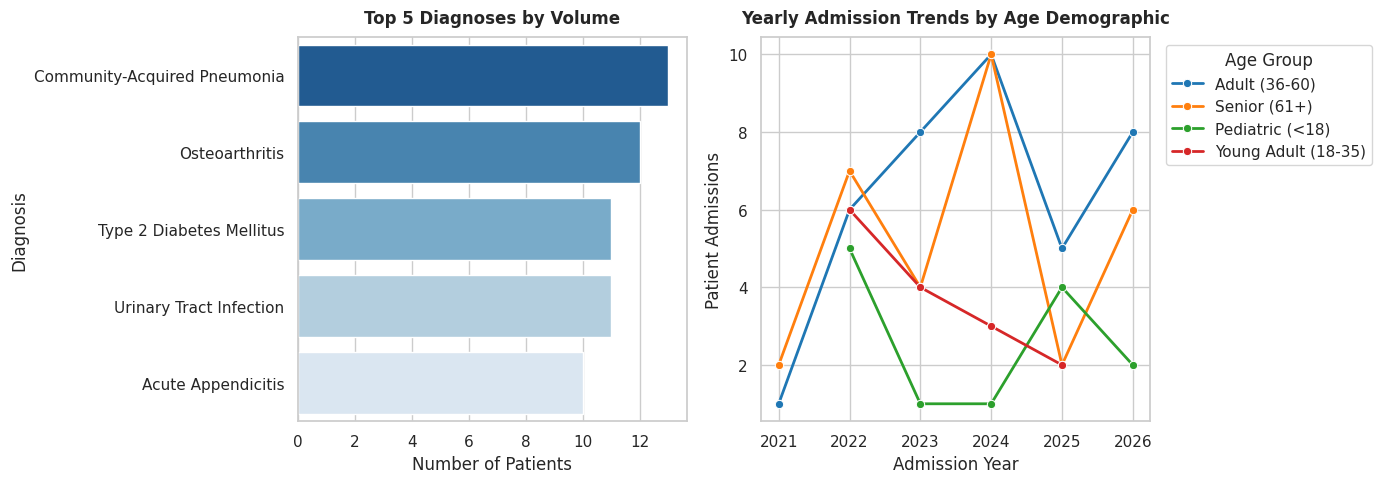

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Load and clean the raw dataset
df = pd.read_csv("synthetic_healthcare_dataset.csv")

# Clean data
df_clean = df.drop_duplicates().copy()
df_clean["age"] = df_clean["age"].fillna(df_clean["age"].mean()).round(0)
df_clean["gender"] = (
    df_clean["gender"].fillna("Unknown").str.strip().replace("", "Unknown")
)
df_clean["diagnosis"] = (
    df_clean["diagnosis"]
    .fillna("Unspecified")
    .str.strip()
    .replace("", "Unspecified")
)
df_clean["treatmenttype"] = (
    df_clean["treatmenttype"]
    .fillna("Unspecified")
    .str.strip()
    .replace("", "Unspecified")
)
df_clean["admission_date"] = pd.to_datetime(
    df_clean["admission_date"], errors="coerce"
)
df_clean = df_clean.dropna(subset=["admission_date"])


# Define age groups
def get_age_group(age):
  if age < 18:
    return "Pediatric (<18)"
  elif age <= 35:
    return "Young Adult (18-35)"
  elif age <= 60:
    return "Adult (36-60)"
  else:
    return "Senior (61+)"


df_clean["age_group"] = df_clean["age"].apply(get_age_group)
df_clean["admission_year"] = df_clean["admission_date"].dt.year

# 2. Set style theme
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Top 5 Diagnoses (For Clinical Ops)
top_diag = (
    df_clean[df_clean["diagnosis"] != "Unspecified"]["diagnosis"]
    .value_counts()
    .head(5)
)
sns.barplot(x=top_diag.values, y=top_diag.index, ax=axes[0], palette="Blues_r")
axes[0].set_title(
    "Top 5 Diagnoses by Volume", fontsize=12, fontweight="bold", pad=10
)
axes[0].set_xlabel("Number of Patients")
axes[0].set_ylabel("Diagnosis")

# Plot 2: Admissions Trend over Time by Age Group (For Executive Leadership)
trend_data = (
    df_clean.groupby(["admission_year", "age_group"]).size().reset_index(name="count")
)
sns.lineplot(
    data=trend_data,
    x="admission_year",
    y="count",
    hue="age_group",
    marker="o",
    linewidth=2,
    ax=axes[1],
    palette="tab10",
)
axes[1].set_title(
    "Yearly Admission Trends by Age Demographic",
    fontsize=12,
    fontweight="bold",
    pad=10,
)
axes[1].set_xlabel("Admission Year")
axes[1].set_ylabel("Patient Admissions")
axes[1].set_xticks(sorted(df_clean["admission_year"].unique()))
axes[1].legend(title="Age Group", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()